In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

# Listening to Real Data

Loading and listening to real datasets here!

In [2]:
from nanodrz.data import DiarizationDataset, libritts_dev
from nanodrz.utils import visualise_annotation, play

duration 18.53106670969045
[2.6222737249451313, 9.422273724945128, 'A']
[10.062273724945129, 17.862273724945126, 'A']
[0.0, 2.1422737249451274, 'A']


[ 00:00:00.000 -->  00:00:02.142] _ A
[ 00:00:02.622 -->  00:00:09.422] _ A
[ 00:00:10.062 -->  00:00:17.862] _ A


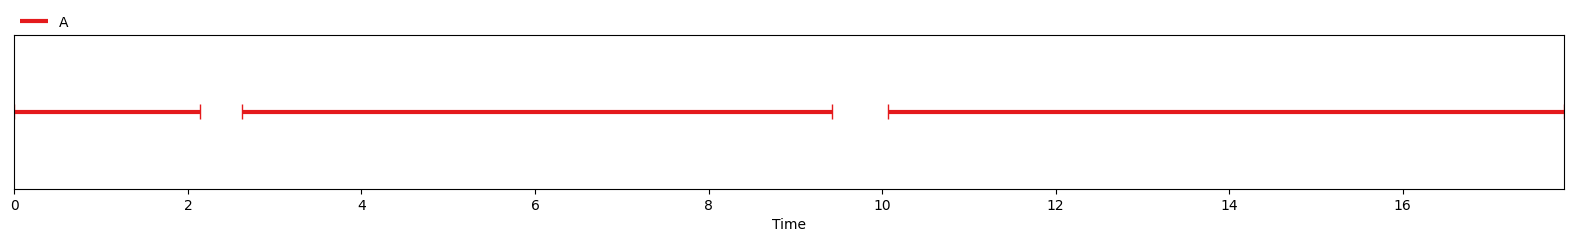

duration 12.556193369042061
[0.0, 6.8113727040800995, 'A']
[7.531372704080098, 12.556193369042063, 'A']


[ 00:00:00.000 -->  00:00:06.811] _ A
[ 00:00:07.531 -->  00:00:12.556] _ A


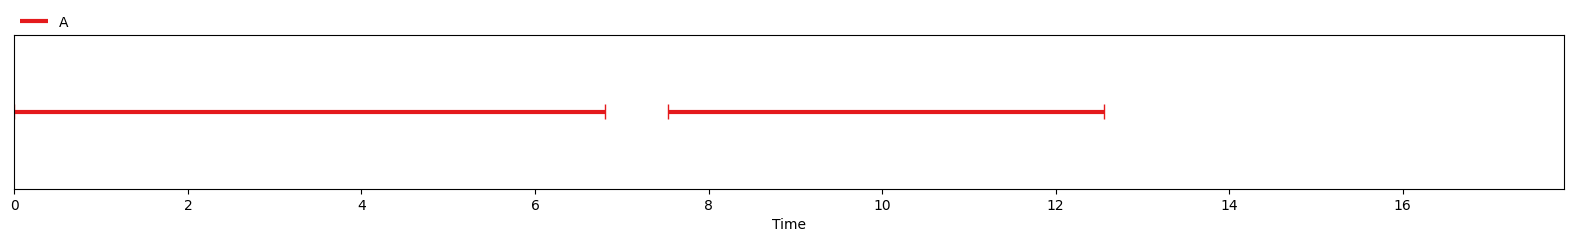

In [3]:
ds = DiarizationDataset("/home/harry/.cache/nanodrz/voxconverse-dev")

for i in range(2):
    audio, l = ds[i]
    print("\n".join([str(li) for li in l]))
    play(audio)
    visualise_annotation(l)

In [4]:
speakers = libritts_dev()

from nanodrz import data
from nanodrz.model import DiarizeGPT

model = DiarizeGPT()
gends = data.GeneratorIterableDataset(
    data.artificial_drz_generator(
        model,
        speakers,
        model.config.model.sample_rate,
    )
)

/home/harry/nanodrz/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


In [ ]:
from torch.utils.data import ChainDataset

chainds = ChainDataset([gends, ds])

for i in chainds:
    audio, l = i    
    print("\n".join([str(li) for li in l]))
    play(audio)
    visualise_annotation(l)